# **1. Perkenalan Dataset**

Dataset yang digunakan pada eksperimen ini adalah **Adult Census Income Dataset**
yang diambil dari Kaggle: https://www.kaggle.com/datasets/uciml/adult-census-income
(bersumber dari UCI Machine Learning Repository).

Dataset ini berisi data sensus penduduk Amerika Serikat dengan **15 kolom** dan
**32.561 baris**. Tujuan dari dataset ini adalah untuk memprediksi apakah
pendapatan seseorang per tahun lebih dari 50K USD (`>50K`) atau kurang dari
sama dengan 50K USD (`<=50K`) berdasarkan atribut demografis dan pekerjaan
(usia, pendidikan, status pernikahan, jam kerja per minggu, dsb).

Task: **Klasifikasi biner** (target: kolom `income`).

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# **3. Memuat Dataset**

In [2]:
df = pd.read_csv("../adult_raw/adult.csv")
print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (32561, 15)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# **4. Exploratory Data Analysis (EDA)**

## 4.1 Cek Missing Value

In [4]:
# Pada dataset ini, missing value direpresentasikan dengan simbol "?"
print("Jumlah NaN standar:")
print(df.isnull().sum())

print("\nJumlah nilai '?' per kolom:")
for col in df.columns:
    if df[col].dtype == object:
        n_missing = (df[col] == "?").sum()
        if n_missing > 0:
            print(f"{col}: {n_missing}")

Jumlah NaN standar:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

Jumlah nilai '?' per kolom:
workclass: 1836
occupation: 1843
native.country: 583


## 4.2 Cek Data Duplikat

In [5]:
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 24


## 4.3 Distribusi Target (income)

income
<=50K    24720
>50K      7841
Name: count, dtype: int64


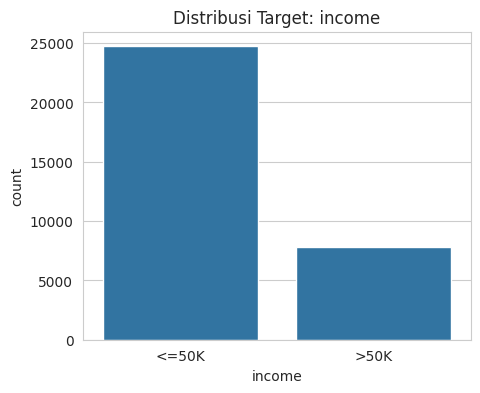

In [6]:
print(df["income"].value_counts())
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="income")
plt.title("Distribusi Target: income")
plt.show()

## 4.4 Statistik Deskriptif Fitur Numerik

In [7]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## 4.5 Distribusi Fitur Numerik

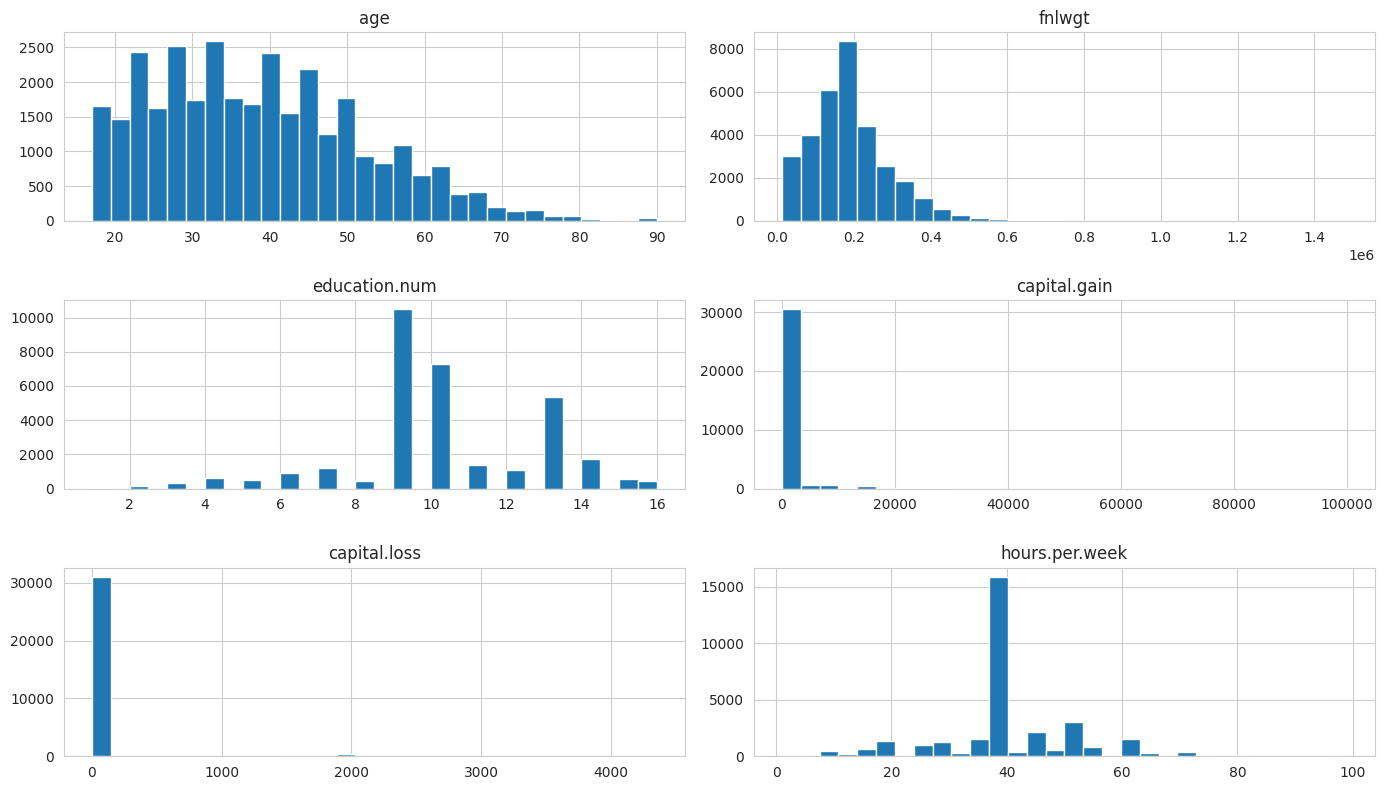

In [8]:
num_cols = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]
df[num_cols].hist(figsize=(14, 8), bins=30)
plt.tight_layout()
plt.show()

## 4.6 Korelasi Antar Fitur Numerik

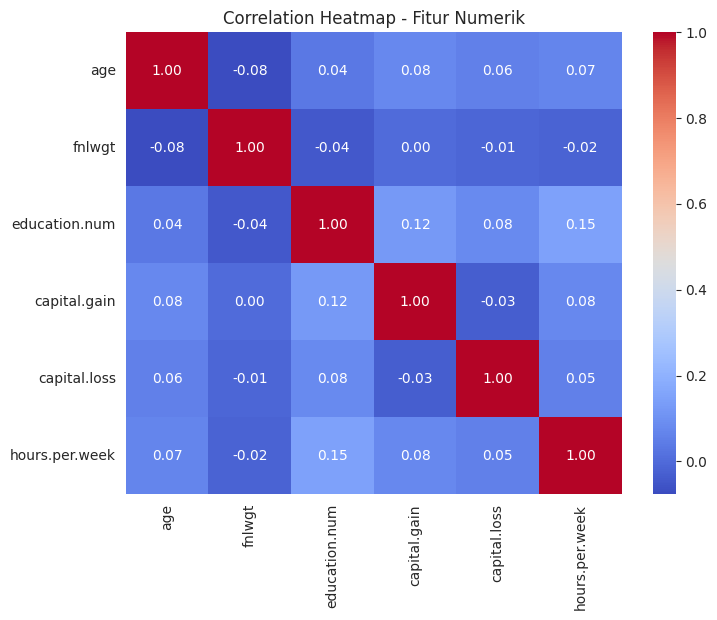

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Fitur Numerik")
plt.show()

## 4.7 Hubungan Fitur Kategorikal dengan Target

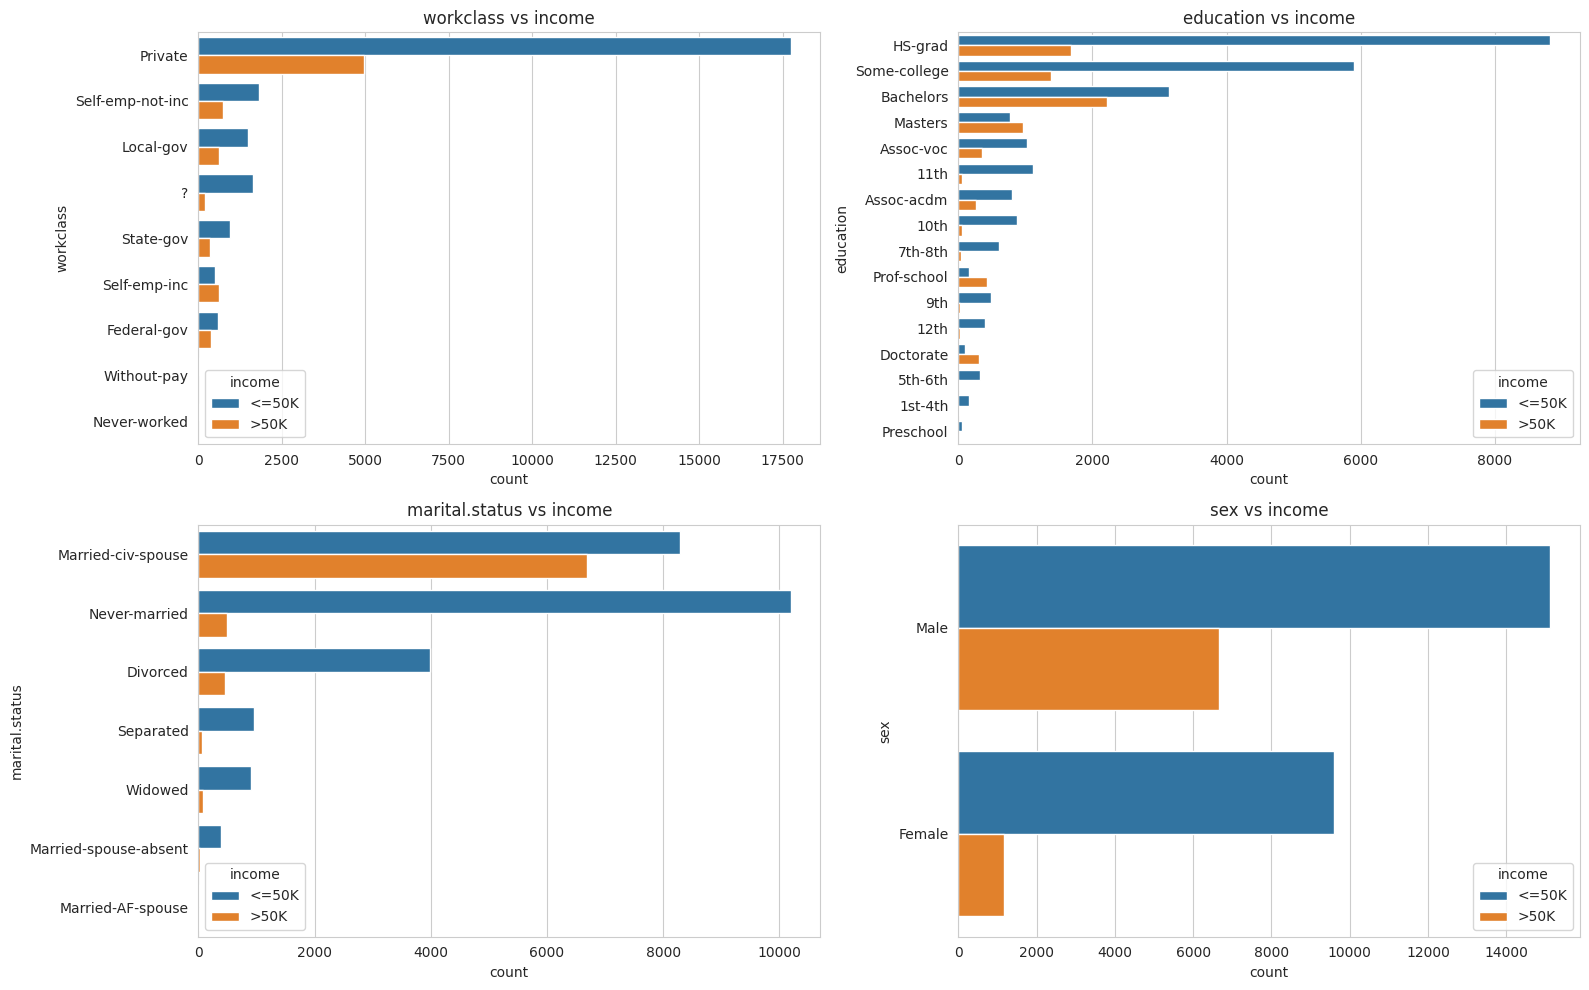

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), ["workclass", "education", "marital.status", "sex"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue="income", order=order, ax=ax)
    ax.set_title(f"{col} vs income")
plt.tight_layout()
plt.show()

**Insight singkat dari EDA:**
- Terdapat nilai `"?"` (bukan NaN standar) pada kolom `workclass`, `occupation`, dan `native.country` yang perlu dibersihkan.
- Target `income` tidak seimbang: mayoritas `<=50K` (± 76%) dibanding `>50K` (± 24%), namun masih dalam batas wajar untuk klasifikasi tanpa perlu resampling agresif.
- Fitur `fnlwgt` memiliki skala yang sangat besar dibanding fitur numerik lain sehingga perlu distandarisasi.
- Individu dengan status `Married-civ-spouse`, pendidikan tinggi (`Bachelors`/`Masters`/`Doctorate`), dan jam kerja lebih panjang cenderung memiliki proporsi `>50K` lebih besar.

# **5. Data Preprocessing**

## 5.1 Menangani Missing Value

In [11]:
df_clean = df.replace("?", np.nan)
df_clean = df_clean.dropna()
print("Ukuran data setelah menghapus missing value:", df_clean.shape)

Ukuran data setelah menghapus missing value: (30162, 15)


## 5.2 Menghapus Data Duplikat

In [12]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Ukuran data setelah menghapus duplikat:", df_clean.shape)

Ukuran data setelah menghapus duplikat: (30139, 15)


## 5.3 Encoding Data Kategorikal

In [13]:
categorical_columns = ["workclass", "education", "marital.status", "occupation",
                       "relationship", "race", "sex", "native.country"]

encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    encoders[col] = le

target_encoder = LabelEncoder()
df_clean["income"] = target_encoder.fit_transform(df_clean["income"].astype(str))
print("Mapping target:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))
df_clean.head()

Mapping target: {'<=50K': np.int64(0), '>50K': np.int64(1)}


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,82,2,132870,11,9,6,3,1,4,0,0,4356,18,38,0
1,54,2,140359,5,4,0,6,4,4,0,0,3900,40,38,0
2,41,2,264663,15,10,5,9,3,4,0,0,3900,40,38,0
3,34,2,216864,11,9,0,7,4,4,0,0,3770,45,38,0
4,38,2,150601,0,6,5,0,4,4,1,0,3770,40,38,0


## 5.4 Standarisasi Fitur Numerik

In [14]:
numerical_columns = ["age", "fnlwgt", "education.num", "capital.gain", "capital.loss", "hours.per.week"]

scaler = StandardScaler()
df_clean[numerical_columns] = scaler.fit_transform(df_clean[numerical_columns])
df_clean.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,3.317157,2,-0.538773,11,-0.440434,6,3,1,4,0,-0.147502,10.551814,-1.914647,38,0
1,1.184832,2,-0.467892,5,-2.402221,0,6,4,4,0,-0.147502,9.424325,-0.078031,38,0
2,0.194824,2,0.708595,15,-0.048076,5,9,3,4,0,-0.147502,9.424325,-0.078031,38,0
3,-0.338257,2,0.256197,11,-0.440434,0,7,4,4,0,-0.147502,9.102892,0.339381,38,0
4,-0.033639,2,-0.370956,0,-1.617506,5,0,4,4,1,-0.147502,9.102892,-0.078031,38,0


## 5.5 Split Data Train dan Test

In [15]:
X = df_clean.drop(columns=["income"])
y = df_clean["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (24111, 14)
X_test : (6028, 14)


## 5.6 Menyimpan Hasil Preprocessing

In [16]:
import os
save_path = "adult_preprocessing"
os.makedirs(save_path, exist_ok=True)

train_df = X_train.copy()
train_df["income"] = y_train
test_df = X_test.copy()
test_df["income"] = y_test

train_df.to_csv(os.path.join(save_path, "train.csv"), index=False)
test_df.to_csv(os.path.join(save_path, "test.csv"), index=False)

print("Data hasil preprocessing berhasil disimpan di folder:", save_path)

Data hasil preprocessing berhasil disimpan di folder: adult_preprocessing


## 5.7 Otomatisasi Preprocessing

Seluruh tahapan preprocessing di atas telah dikonversi menjadi satu fungsi
otomatis pada file `automate_Gilang-Swandaru.py` (fungsi `preprocess_data`)
agar proses ini dapat dijalankan ulang secara otomatis (termasuk melalui
GitHub Actions) tanpa perlu menjalankan notebook secara manual.

In [17]:
import importlib.util

spec = importlib.util.spec_from_file_location("automate_module", "automate_Gilang-Swandaru.py")
automate_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(automate_module)

X_train2, X_test2, y_train2, y_test2 = automate_module.preprocess_data(
    data_path="../adult_raw/adult.csv",
    save_path="adult_preprocessing"
)

[INFO] Preprocessing selesai. Train shape: (24111, 15), Test shape: (6028, 15)
[INFO] Hasil disimpan di: adult_preprocessing
